# Análisis de Sentimientos en Reseñas de Productos en Español
  Dataset: Multilingual Amazon Reviews Corpus (Kaggle)
  
  Objetivo: Predecir si una reseña es positiva, neutra o negativa

In [35]:
import pandas as pd

# Cargar los datos
df_train = pd.read_csv("../data/train.csv")
df_test = pd.read_csv("../data/test.csv")
df_val = pd.read_csv("../data/validation.csv")

print("Train:", df_train.shape)
print("Test:", df_test.shape)
print("Validation:", df_val.shape)

Train: (1200000, 9)
Test: (30000, 9)
Validation: (30000, 9)


In [36]:
# Ver las primeras filas
df_train.head()

,Unnamed: 0,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category
0,0,de_0203609,product_de_0865382,reviewer_de_0267719,1,Armband ist leider nach 1 Jahr kaputt gegangen,Leider nach 1 Jahr kaputt,de,sports
1,1,de_0559494,product_de_0678997,reviewer_de_0783625,1,In der Lieferung war nur Ein Akku!,EINS statt ZWEI Akkus!!!,de,home_improvement
2,2,de_0238777,product_de_0372235,reviewer_de_0911426,1,"Ein Stern, weil gar keine geht nicht. Es hande...",Achtung Abzocke,de,drugstore
3,3,de_0477884,product_de_0719501,reviewer_de_0836478,1,"Dachte, das wären einfach etwas festere Binden...",Zu viel des Guten,de,drugstore
4,4,de_0270868,product_de_0022613,reviewer_de_0736276,1,Meine Kinder haben kaum damit gespielt und nac...,Qualität sehr schlecht,de,toy


In [37]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200000 entries, 0 to 1199999
Data columns (total 9 columns):
 #   Column            Non-Null Count    Dtype
---  ------            --------------    -----
 0   Unnamed: 0        1200000 non-null  int64
 1   review_id         1200000 non-null  str  
 2   product_id        1200000 non-null  str  
 3   reviewer_id       1200000 non-null  str  
 4   stars             1200000 non-null  int64
 5   review_body       1200000 non-null  str  
 6   review_title      1199957 non-null  str  
 7   language          1200000 non-null  str  
 8   product_category  1200000 non-null  str  
dtypes: int64(2), str(7)
memory usage: 393.4 MB


In [38]:
# Filtrar solo reseñas en español
df_es = df_train[df_train['language'] == 'es']
print("Reseñas en español:", df_es.shape)
print("Distribución de estrellas:")
print(df_es['stars'].value_counts().sort_index())

Reseñas en español: (200000, 9)
Distribución de estrellas:
stars
1    40000
2    40000
3    40000
4    40000
5    40000
Name: count, dtype: int64


In [39]:
# Crear etiquetas de sentimiento
def crear_etiqueta(estrellas):
    if estrellas >= 4:
        return "positivo"
    elif estrellas == 3:
        return "neutro"
    else:
        return "negativo"

df_es['sentimiento'] = df_es['stars'].apply(crear_etiqueta)
print("Distribución de sentimientos:")
print(df_es['sentimiento'].value_counts())

Distribución de sentimientos:
sentimiento
negativo    80000
positivo    80000
neutro      40000
Name: count, dtype: int64


In [40]:
# Ver algunas reseñas
df_es[['review_body', 'sentimiento']].sample(5)

,review_body,sentimiento
519097,Articulo de muy buena calidad y facil de monta...,neutro
576590,"Muy buenas, pegan mucho y es un corcho muy bueno.",positivo
478192,La bateria dura poco tiempo. Y la aplicacion n...,negativo
440315,Buena relación calidad precio,negativo
439385,Muy mal porque lo pedí hace un montón de tiemp...,negativo


In [41]:
# Guardar el dataset en español
df_es.to_csv("../data/amazon_resenas_español.csv", index=False)
print("Archivo guardado exitosamente!")

Archivo guardado exitosamente!


In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

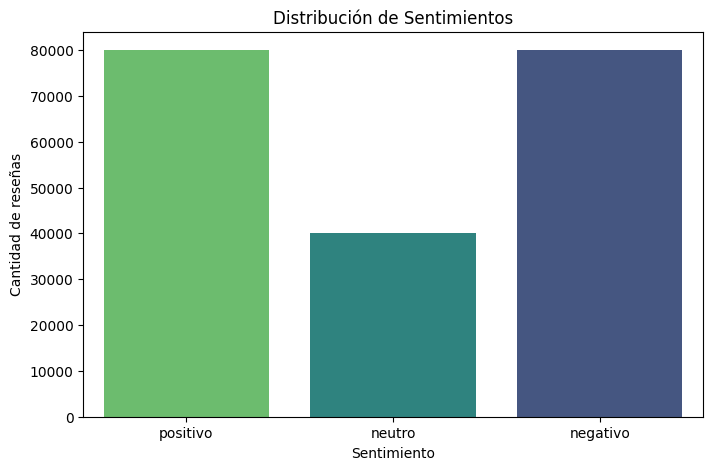

In [44]:
# Distribución de sentimientos
plt.figure(figsize=(8, 5))
sns.countplot(data=df_es, x='sentimiento', hue='sentimiento', palette='viridis', 
              order=['positivo', 'neutro', 'negativo'], legend=False)
plt.title('Distribución de Sentimientos')
plt.xlabel('Sentimiento')
plt.ylabel('Cantidad de reseñas')
plt.show()

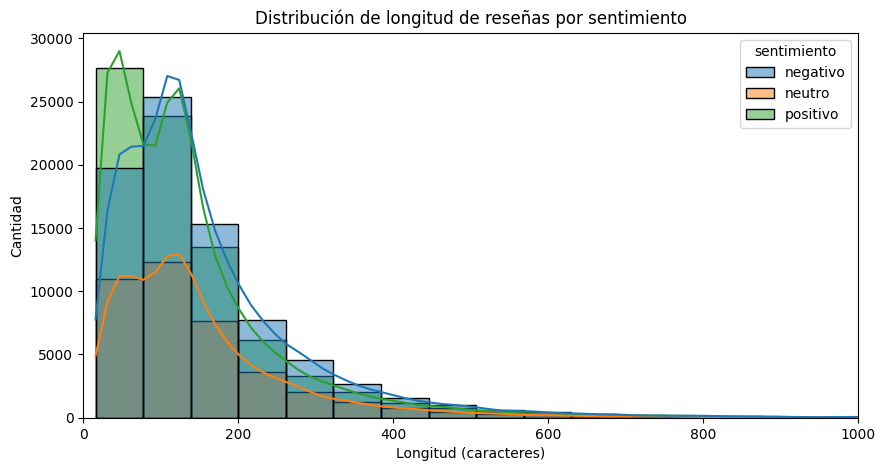

In [45]:
# Longitud de las reseñas
df_es['longitud'] = df_es['review_body'].apply(len)

plt.figure(figsize=(10, 5))
sns.histplot(data=df_es, x='longitud', hue='sentimiento', bins=50, kde=True)
plt.title('Distribución de longitud de reseñas por sentimiento')
plt.xlabel('Longitud (caracteres)')
plt.ylabel('Cantidad')
plt.xlim(0, 1000)
plt.show()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\alega\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


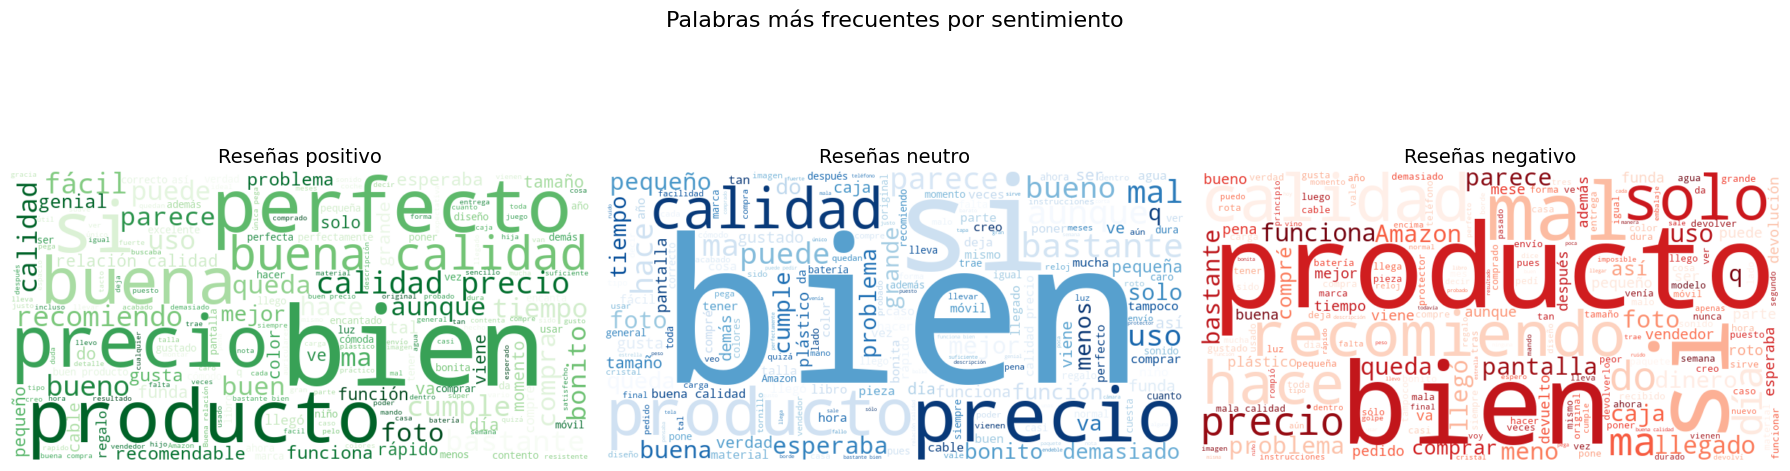

In [46]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('spanish'))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sentimientos = ['positivo', 'neutro', 'negativo']
colores = ['Greens', 'Blues', 'Reds']

for i, (sentimiento, color) in enumerate(zip(sentimientos, colores)):
    texto = ' '.join(df_es[df_es['sentimiento'] == sentimiento]['review_body'].sample(5000))
    wordcloud = WordCloud(width=800, height=400, background_color='white',
                         colormap=color, stopwords=stop_words).generate(texto)
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(f'Reseñas {sentimiento}', fontsize=14)
    axes[i].axis('off')

plt.suptitle('Palabras más frecuentes por sentimiento', fontsize=16)
plt.tight_layout()
plt.show()

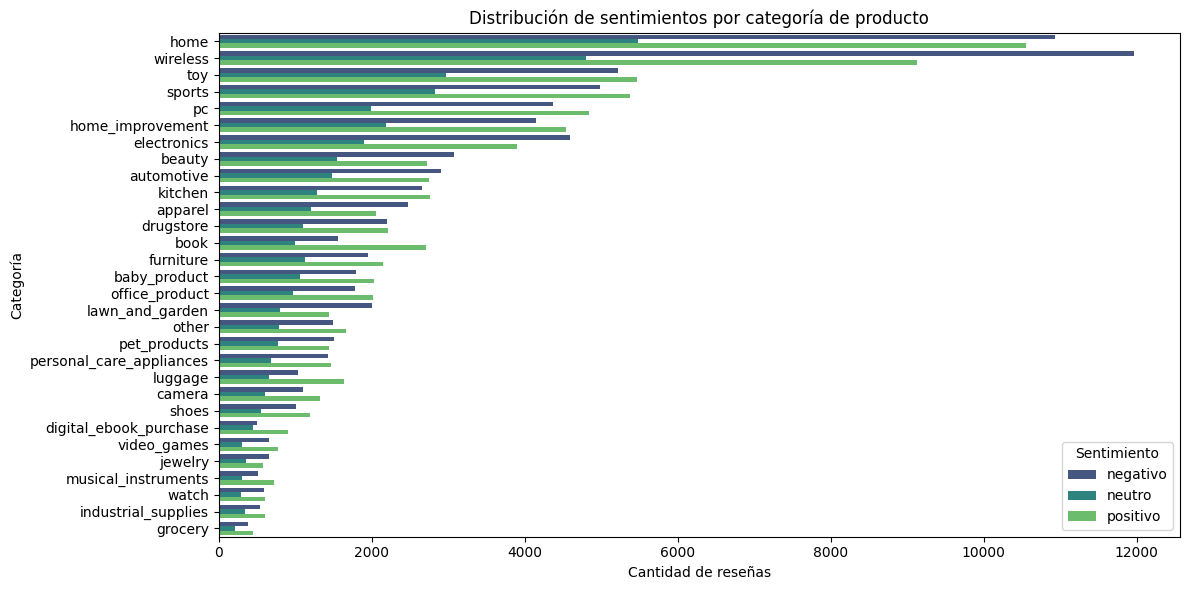

In [47]:
# Distribución por categoría de producto
plt.figure(figsize=(12, 6))
sns.countplot(data=df_es, y='product_category', hue='sentimiento',
              order=df_es['product_category'].value_counts().index,
              palette='viridis')
plt.title('Distribución de sentimientos por categoría de producto')
plt.xlabel('Cantidad de reseñas')
plt.ylabel('Categoría')
plt.legend(title='Sentimiento')
plt.tight_layout()
plt.show()

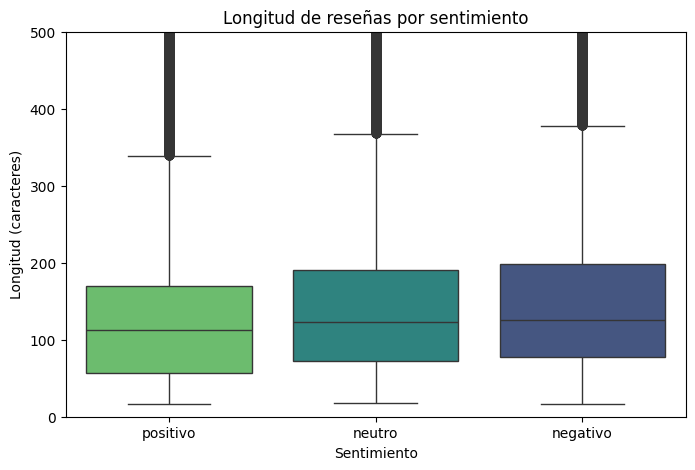

In [48]:
# Boxplot de longitud por sentimiento
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_es, x='sentimiento', y='longitud', 
            hue='sentimiento', palette='viridis',
            order=['positivo', 'neutro', 'negativo'], legend=False)
plt.title('Longitud de reseñas por sentimiento')
plt.xlabel('Sentimiento')
plt.ylabel('Longitud (caracteres)')
plt.ylim(0, 500)
plt.show()

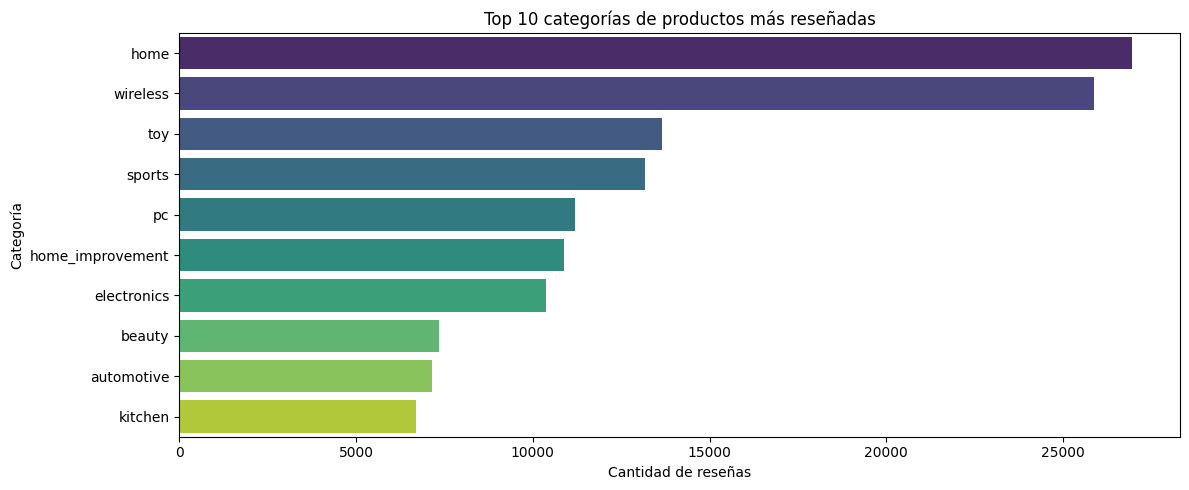

In [49]:
# Top 10 categorías de productos
plt.figure(figsize=(12, 5))
top_categorias = df_es['product_category'].value_counts().head(10)
sns.barplot(x=top_categorias.values, y=top_categorias.index, 
            hue=top_categorias.index, palette='viridis', legend=False)
plt.title('Top 10 categorías de productos más reseñadas')
plt.xlabel('Cantidad de reseñas')
plt.ylabel('Categoría')
plt.tight_layout()
plt.show()

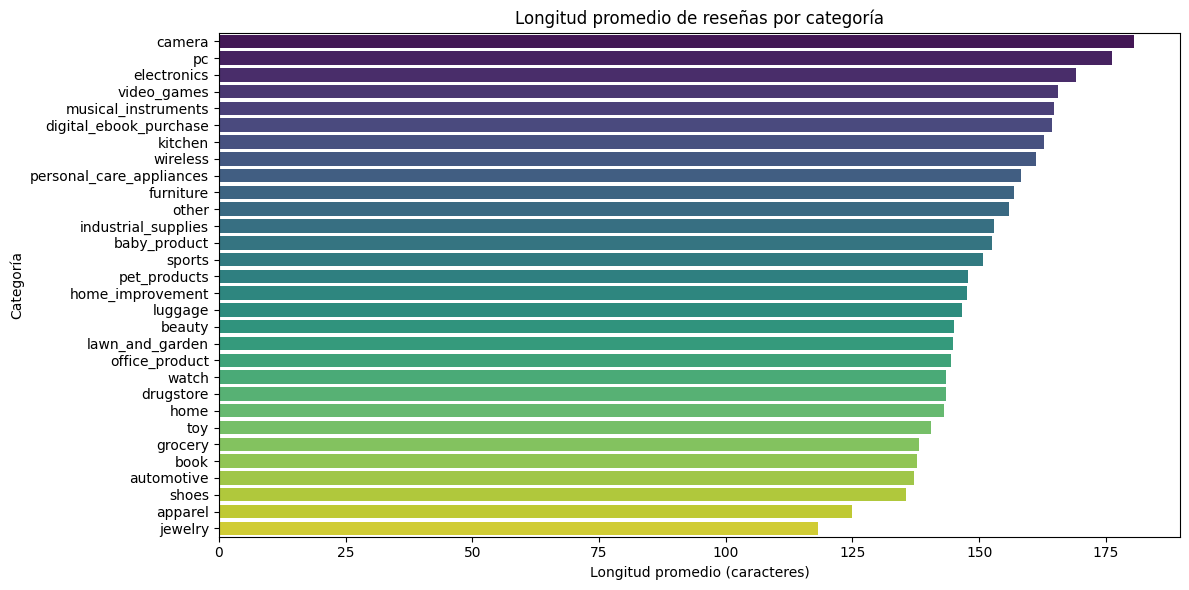

In [50]:
# Longitud promedio por categoría
plt.figure(figsize=(12, 6))
longitud_categoria = df_es.groupby('product_category')['longitud'].mean().sort_values(ascending=False)
sns.barplot(x=longitud_categoria.values, y=longitud_categoria.index,
            hue=longitud_categoria.index, palette='viridis', legend=False)
plt.title('Longitud promedio de reseñas por categoría')
plt.xlabel('Longitud promedio (caracteres)')
plt.ylabel('Categoría')
plt.tight_layout()
plt.show()

In [51]:
# Limpiar Texto
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('spanish'))

# Conservar palabras de negación — son críticas para el sentimiento
negaciones = {'no', 'nada', 'nunca', 'jamás', 'ningún', 
              'ninguna', 'tampoco', 'sin', 'ni', 'pero'}
stop_words_filtradas = stop_words - negaciones

def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'\d+', '', texto)
    texto = re.sub(r'[^\w\s]', '', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    palabras = texto.split()
    palabras = [p for p in palabras if p not in stop_words_filtradas]
    return ' '.join(palabras)

df_es['review_body_limpio'] = df_es['review_body'].apply(limpiar_texto)
df_es['review_title_limpio'] = df_es['review_title'].fillna('').apply(limpiar_texto)

print("Ejemplo original:")
print(df_es['review_body'].iloc[0])
print("\nEjemplo limpio:")
print(df_es['review_body_limpio'].iloc[0])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\alega\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Ejemplo original:
Nada bueno se me fue ka pantalla en menos de 8 meses y no he recibido respuesta del fabricante

Ejemplo limpio:
nada bueno ka pantalla menos meses no recibido respuesta fabricante


In [52]:
# Ingeniería de características
df_es['longitud_body'] = df_es['review_body'].apply(len)
df_es['num_palabras'] = df_es['review_body'].apply(lambda x: len(x.split()))
df_es['num_palabras_unicas'] = df_es['review_body'].apply(lambda x: len(set(x.split())))
df_es['promedio_longitud_palabras'] = df_es['review_body'].apply(lambda x: sum(len(w) for w in x.split()) / len(x.split()) if len(x.split()) > 0 else 0)
df_es['num_exclamaciones'] = df_es['review_body'].apply(lambda x: x.count('!'))
df_es['num_interrogaciones'] = df_es['review_body'].apply(lambda x: x.count('?'))
df_es['num_mayusculas'] = df_es['review_body'].apply(lambda x: sum(1 for c in x if c.isupper()))
df_es['proporcion_stopwords'] = df_es['review_body'].apply(lambda x: sum(1 for w in x.lower().split() if w in stop_words) / len(x.split()) if len(x.split()) > 0 else 0)
df_es['longitud_titulo'] = df_es['review_title'].fillna('').apply(len)
df_es['num_palabras_titulo'] = df_es['review_title'].fillna('').apply(lambda x: len(x.split()))

print("Nuevas features creadas:")
print(df_es[['longitud_body', 'num_palabras', 'num_palabras_unicas', 
             'promedio_longitud_palabras', 'num_exclamaciones',
             'num_interrogaciones', 'num_mayusculas', 'proporcion_stopwords',
             'longitud_titulo', 'num_palabras_titulo']].head())

Nuevas features creadas:
        longitud_body  num_palabras  num_palabras_unicas  \
400000             94            19                   19   
400001            140            23                   20   
400002            117            22                   19   
400003            332            60                   53   
400004             36             7                    7   

        promedio_longitud_palabras  num_exclamaciones  num_interrogaciones  \
400000                    4.000000                  0                    0   
400001                    5.130435                  0                    0   
400002                    4.363636                  2                    0   
400003                    4.550000                  0                    0   
400004                    4.285714                  0                    0   

        num_mayusculas  proporcion_stopwords  longitud_titulo  \
400000               1              0.526316               16   
400001         

In [53]:
# Guardar dataset con features
df_es.to_csv("../data/amazon_resenas_features.csv", index=False)
print("Dataset con features guardado!")
print(f"Total columnas: {df_es.shape[1]}")
print(f"Total filas: {df_es.shape[0]}")

Dataset con features guardado!
Total columnas: 23
Total filas: 200000


In [54]:
# Preparación de datos para el modelo
from sklearn.model_selection import train_test_split

# Variables predictoras y target
X = df_es['review_body_limpio']
y = df_es['sentimiento']

# División estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Tamaño train:", X_train.shape)
print("Tamaño test:", X_test.shape)
print("\nDistribución train:")
print(y_train.value_counts())
print("\nDistribución test:")
print(y_test.value_counts())

Tamaño train: (160000,)
Tamaño test: (40000,)

Distribución train:
sentimiento
negativo    64000
positivo    64000
neutro      32000
Name: count, dtype: int64

Distribución test:
sentimiento
positivo    16000
negativo    16000
neutro       8000
Name: count, dtype: int64


In [55]:
# Convertir texto en números
from sklearn.feature_extraction.text import TfidfVectorizer

# Crear el vectorizador TF-IDF
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

# Entrenar con train y transformar ambos
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Shape train TF-IDF:", X_train_tfidf.shape)
print("Shape test TF-IDF:", X_test_tfidf.shape)

Shape train TF-IDF: (160000, 5000)
Shape test TF-IDF: (40000, 5000)


In [56]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Codificar el target
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print("Clases:", le.classes_)

# Entrenar XGBoost
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
xgb.fit(X_train_tfidf, y_train_enc)
print("Modelo entrenado!")

Clases: ['negativo' 'neutro' 'positivo']
Modelo entrenado!


In [57]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Muestra pequeña para que no tarde horas
X_train_sample = X_train_tfidf[:10000]
y_train_sample = y_train_enc[:10000]

# Parámetros a probar
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.7, 0.8, 1.0]
}

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss'),
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    random_state=42,
    verbose=1
)

random_search.fit(X_train_sample, y_train_sample)

print("Mejores parámetros:", random_search.best_params_)
print("Mejor accuracy:", random_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Mejores parámetros: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.3}
Mejor accuracy: 0.6629997432856664


In [58]:
from sklearn.metrics import classification_report

# Evaluar modelo con mejores parámetros
mejor_xgb = random_search.best_estimator_

print("Mejores parámetros encontrados:", random_search.best_params_)

y_pred_mejor = mejor_xgb.predict(X_test_tfidf)

print("\nReporte modelo mejorado:")
print(classification_report(y_test_enc, y_pred_mejor, target_names=le.classes_))

Mejores parámetros encontrados: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.3}

Reporte modelo mejorado:
              precision    recall  f1-score   support

    negativo       0.71      0.79      0.75     16000
      neutro       0.39      0.24      0.29      8000
    positivo       0.74      0.80      0.77     16000

    accuracy                           0.68     40000
   macro avg       0.61      0.61      0.60     40000
weighted avg       0.66      0.68      0.67     40000



In [59]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predicciones
y_pred = xgb.predict(X_test_tfidf)

# Reporte de clasificación
print("Reporte de clasificación:")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

Reporte de clasificación:
              precision    recall  f1-score   support

    negativo       0.72      0.81      0.77     16000
      neutro       0.47      0.21      0.29      8000
    positivo       0.73      0.84      0.78     16000

    accuracy                           0.70     40000
   macro avg       0.64      0.62      0.61     40000
weighted avg       0.68      0.70      0.68     40000



Por clase:

Positivo: F1 = 0.78 — el modelo detecta bien las reseñas positivas
Negativo: F1 = 0.77 — también detecta bien las negativas
Neutro: F1 = 0.29 — el modelo le cuesta identificar reseñas neutras

Accuracy = 70% — de cada 10 reseñas, acierta 7

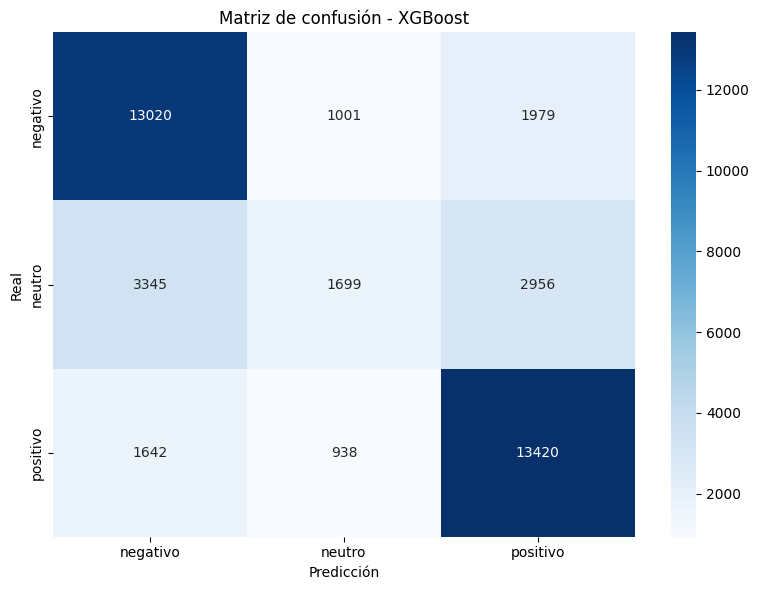

In [24]:
# Matriz de confusión
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_enc, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Matriz de confusión - XGBoost')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

In [25]:
print(cm)
print("\nSuma por fila:")
print(cm.sum(axis=1))

[[13020  1001  1979]
 [ 3345  1699  2956]
 [ 1642   938 13420]]

Suma por fila:
[16000  8000 16000]


In [26]:
import pickle

# Guardar el modelo XGBoost
with open('../models/modelo_xgboost.pkl', 'wb') as f:
    pickle.dump(xgb, f)

# Guardar también el vectorizador TF-IDF y el LabelEncoder
with open('../models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

with open('../models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Modelo, vectorizador y encoder guardados!")


Modelo, vectorizador y encoder guardados!


In [27]:
# =============================================
# Red Neuronal
# =============================================

import pandas as pd
import numpy as np
from nltk.corpus import stopwords
import re

# Cargar dataset con features ya creadas
df_es = pd.read_csv("../data/amazon_resenas_features.csv")

print("Dataset cargado!")
print(df_es.shape)
print(df_es['sentimiento'].value_counts())

Dataset cargado!
(200000, 23)
sentimiento
negativo    80000
positivo    80000
neutro      40000
Name: count, dtype: int64


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Variables
X = df_es['review_body_limpio']
y = df_es['sentimiento']

# División estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Codificar el target
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print("Clases:", le.classes_)
print("Train:", X_train.shape)
print("Test:", X_test.shape)

Clases: ['negativo' 'neutro' 'positivo']
Train: (160000,)
Test: (40000,)


In [29]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Rellenar valores nulos
X_train = X_train.fillna('').astype(str)
X_test = X_test.fillna('').astype(str)

print("Valores nulos en train:", X_train.isnull().sum())
print("Valores nulos en test:", X_test.isnull().sum())

# Crear el tokenizer
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')

# Entrenar con los datos de train
tokenizer.fit_on_texts(X_train)

# Convertir texto a secuencias de números
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Hacer todas las secuencias del mismo largo
X_train_pad = pad_sequences(X_train_seq, maxlen=100, truncating='post', padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=100, truncating='post', padding='post')

print("Shape train:", X_train_pad.shape)
print("Shape test:", X_test_pad.shape)
print("\nEjemplo de reseña convertida:")
print(X_train_pad[0])

Valores nulos en train: 0
Valores nulos en test: 0
Shape train: (160000, 100)
Shape test: (40000, 100)

Ejemplo de reseña convertida:
[   1  151  692   72  317  165 1831 6833   70   91    1    1 7013   16
    4    6    1 1721    1 5024    2 6111    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]


In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout

# Construir la red neuronal
model = Sequential([
    Embedding(input_dim=10000, output_dim=64),
    GlobalAveragePooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [31]:
# Entrenar la red neuronal
history = model.fit(
    X_train_pad, y_train_enc,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.6417 - loss: 0.8105 - val_accuracy: 0.6579 - val_loss: 0.7926
Epoch 2/10
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.7003 - loss: 0.7001 - val_accuracy: 0.6829 - val_loss: 0.7541
Epoch 3/10
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.7109 - loss: 0.6773 - val_accuracy: 0.7055 - val_loss: 0.6914
Epoch 4/10
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.7170 - loss: 0.6643 - val_accuracy: 0.6832 - val_loss: 0.7474
Epoch 5/10
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.7227 - loss: 0.6528 - val_accuracy: 0.7112 - val_loss: 0.6748
Epoch 6/10
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.7272 - loss: 0.6415 - val_accuracy: 0.7086 - val_loss: 0.6809
Epoch 7/10
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.7296 - loss: 0.6334 - val_accuracy: 0.6848 - val_loss: 0.7323
Epoch 8/10
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.7335 - loss: 0

In [32]:
from sklearn.metrics import classification_report, confusion_matrix

# Predicciones
y_pred_nn = model.predict(X_test_pad)
y_pred_nn_classes = y_pred_nn.argmax(axis=1)

# Reporte de clasificación
print("Reporte de clasificación - Red Neuronal:")
print(classification_report(y_test_enc, y_pred_nn_classes, target_names=le.classes_))


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 888us/step
Reporte de clasificación - Red Neuronal:
              precision    recall  f1-score   support

    negativo       0.71      0.89      0.79     16000
      neutro       0.47      0.18      0.26      8000
    positivo       0.78      0.83      0.80     16000

    accuracy                           0.72     40000
   macro avg       0.65      0.63      0.62     40000
weighted avg       0.69      0.72      0.69     40000



In [33]:
import pickle

# Guardar la red neuronal
model.save('../models/modelo_red_neuronal.keras')

# Guardar el tokenizer
with open('../models/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

print("Red neuronal y tokenizer guardados!")


Red neuronal y tokenizer guardados!


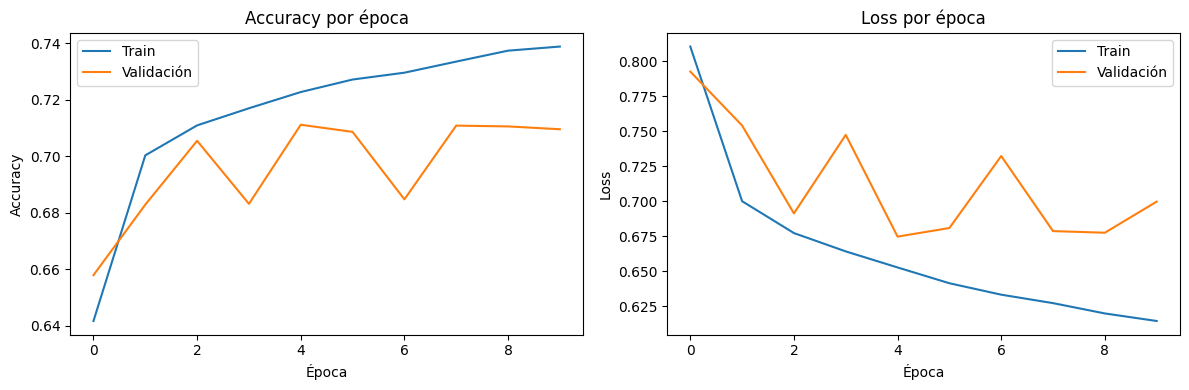

In [34]:
# Curva de aprendizaje
plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Accuracy por época')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Loss por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
